# O1 — MPC mastery (concept + implementation)
* Understand MPC mathematically, practically, and statistically.
* Know exactly how preprocessing choices (filter, Hilbert, phase unwrap, edge effects) change results.
* Establish “MPC is high” ≠ “true coupling” unless confounds are ruled out.

These are the “characteristics” backed up with controlled experiments:

### D. Noise / SNR dependence

Adding noise randomizes instantaneous phase → MPC typically decreases; BUT the interaction with filtering can be non-intuitive.

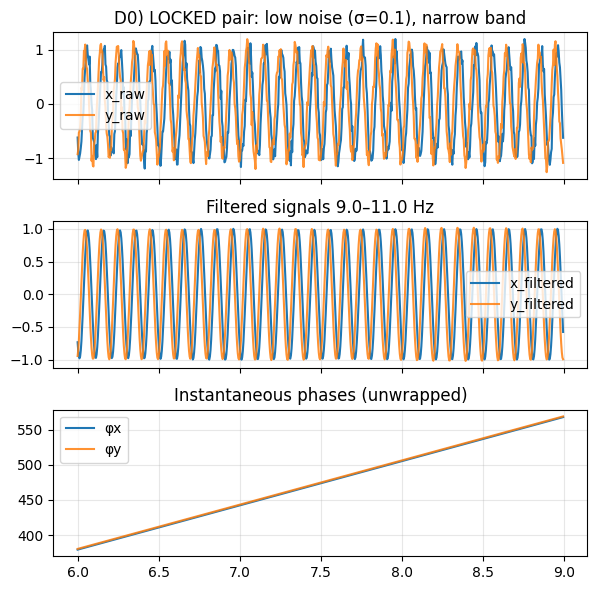

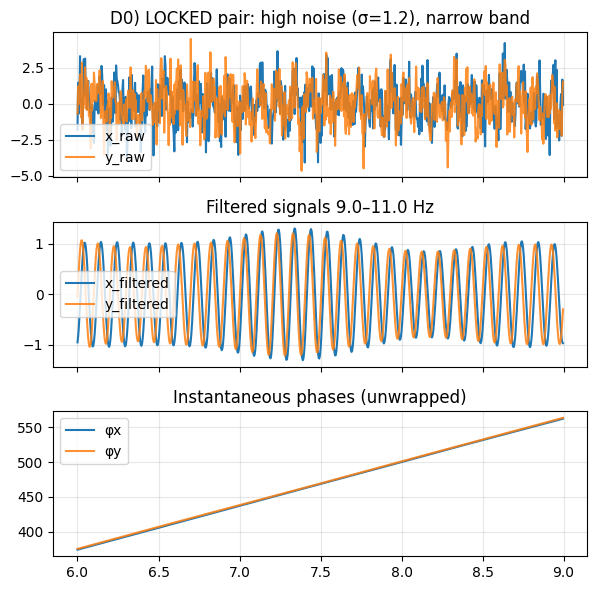

Independent pure-noise — narrow (9–11 Hz):   0%|          | 0/8 [00:00<?, ?it/s]

Independent pure-noise — wide (6–16 Hz):   0%|          | 0/8 [00:00<?, ?it/s]

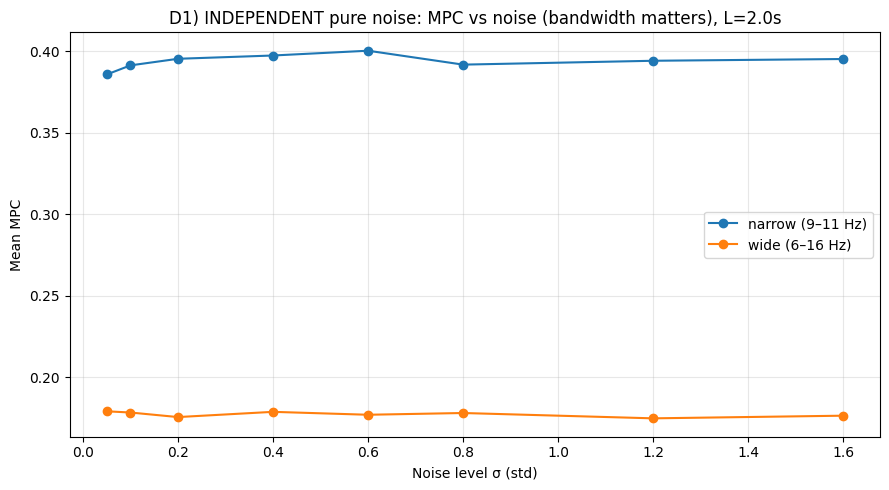

Locked — narrow (9–11 Hz):   0%|          | 0/8 [00:00<?, ?it/s]

Locked — wide (6–16 Hz):   0%|          | 0/8 [00:00<?, ?it/s]

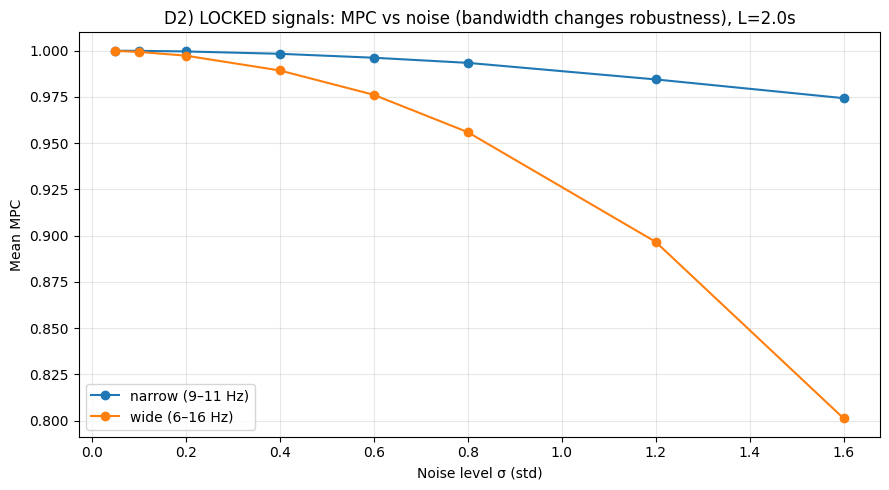

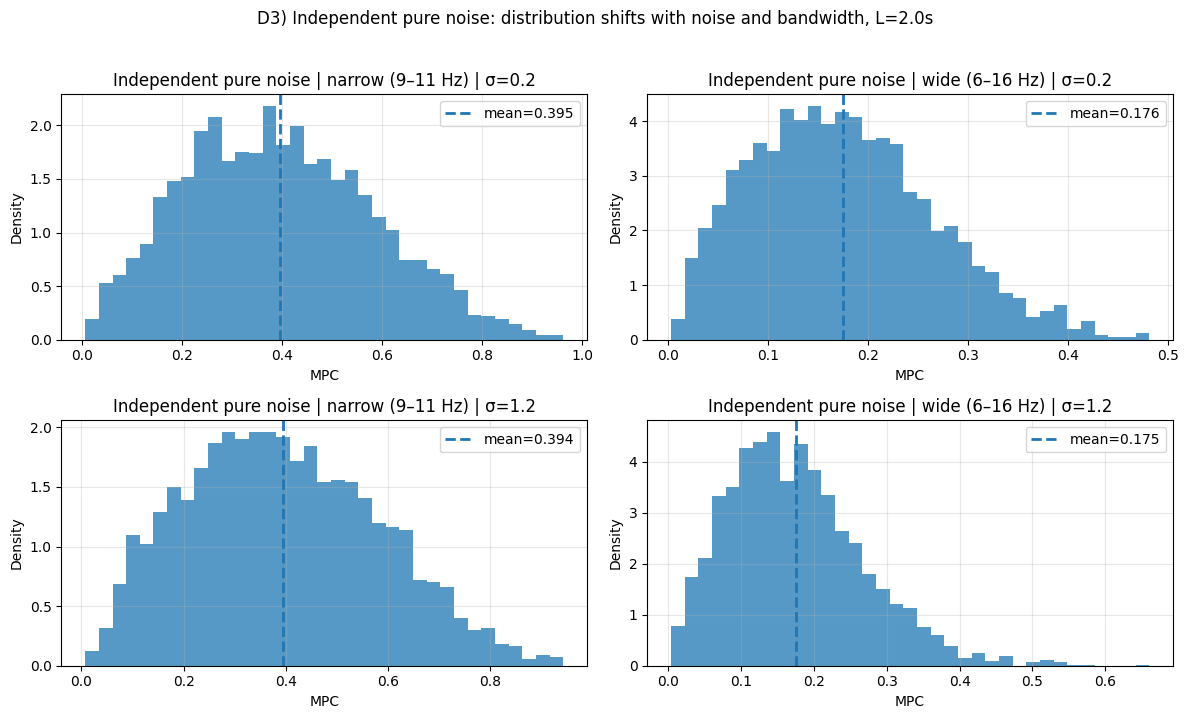

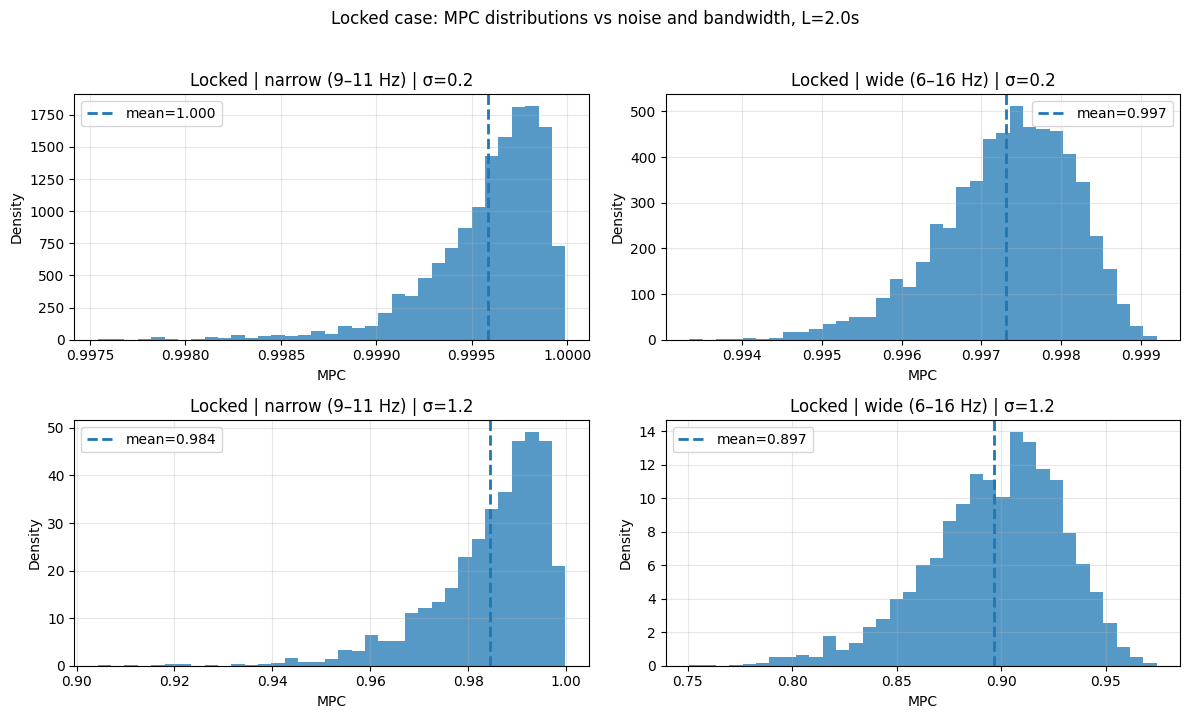

In [7]:
# ============================================================
# O1.D — Noise / SNR dependence
#
#
# - "Independent" case is truly independent baseline:
#     independent PURE NOISE signals (no sinusoid)
#   then bandpass + Hilbert + phase + MPC.
#
# - "Locked" case remains:
#     same-frequency sinusoids with fixed phase offset + noise
#
# Why this matters:
# - Using pure noise cleanly separates:
#     (A) spurious MPC from preprocessing under independence
#     (B) genuine phase locking under a fixed phase offset
#
# Outputs:
# D0) Pipeline demo (locked) low vs high noise (narrow band)
# D1) Independent pure-noise: mean MPC vs noise, narrow vs wide band
# D2) Locked: mean MPC vs noise, narrow vs wide band
# D3) Optional histograms (independent case) at low vs high noise
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg

# Optional progress bar
try:
    from tqdm.auto import tqdm
    _tqdm = tqdm
except Exception:
    def _tqdm(x, **kwargs):
        return x

rng = np.random.default_rng(0)

# ------------------- settings -------------------
fs = 256
T = 20.0
n = int(T * fs)
t = np.arange(n) / fs

f0 = 10.0
amp = 1.0

# Noise grid (std of additive noise)
noise_levels = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.2, 1.6])

# Two bandwidths to reveal the interaction clearly
bands = {
    "narrow (9–11 Hz)": (9.0, 11.0),
    "wide (6–16 Hz)":   (6.0, 16.0),
}
order = 4

# Window length for MPC evaluation
L = 2.0
W = int(L * fs)

# Monte Carlo reps
n_pairs = 250
n_windows_per_pair = 10

edge_trim_s = 1.0
edge_trim = int(edge_trim_s * fs)

# ------------------- helpers -------------------
def bandpass_filter(x, fs, band, order=4):
    sos = sg.butter(order, band, btype="bandpass", fs=fs, output="sos")
    return sg.sosfiltfilt(sos, x)

def hilbert_phase(x_filt):
    xa = sg.hilbert(x_filt)
    return xa, np.unwrap(np.angle(xa))

def mpc_from_phases(phi_x, phi_y):
    dphi = phi_x - phi_y
    return np.abs(np.mean(np.exp(1j * dphi)))

def sample_windows(phi_x, phi_y, W, n_windows):
    max_start = len(phi_x) - W
    starts = rng.integers(0, max_start, size=n_windows)
    vals = np.empty(n_windows, dtype=float)
    for k, s in enumerate(starts):
        vals[k] = mpc_from_phases(phi_x[s:s+W], phi_y[s:s+W])
    return vals

# ---  generators ---

def make_independent_pure_noise(noise_std):
    # Independent baseline: no oscillatory component at all
    x = noise_std * rng.standard_normal(n)
    y = noise_std * rng.standard_normal(n)
    return x, y

def make_locked_pair(noise_std, amp=1.0, fixed_phase=1.0):
    # True locking: same oscillator phase + fixed offset, plus independent additive noise
    ph0 = rng.uniform(0, 2*np.pi)
    x = amp*np.sin(2*np.pi*f0*t + ph0) + noise_std*rng.standard_normal(n)
    y = amp*np.sin(2*np.pi*f0*t + ph0 + fixed_phase) + noise_std*rng.standard_normal(n)
    return x, y

# ============================================================
# D0) PIPELINE DEMO (locked) — low vs high noise (narrow band)
# ============================================================
def pipeline_demo_locked(noise_std, band, title):
    x_raw, y_raw = make_locked_pair(noise_std, amp=amp, fixed_phase=1.0)

    x_f = bandpass_filter(x_raw, fs, band, order)
    y_f = bandpass_filter(y_raw, fs, band, order)

    xa, phx = hilbert_phase(x_f)
    ya, phy = hilbert_phase(y_f)

    # trim edges
    sl = slice(edge_trim, -edge_trim)
    tt = t[sl]
    x_raw, y_raw = x_raw[sl], y_raw[sl]
    x_f, y_f = x_f[sl], y_f[sl]
    xa, ya = xa[sl], ya[sl]
    phx, phy = phx[sl], phy[sl]
    dphi = phx - phy
    Ax = np.abs(xa)
    Ay = np.abs(ya)

    # zoom
    z0 = int(5.0 * fs)
    z1 = z0 + int(3.0 * fs)

    fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

    axes[0].plot(tt[z0:z1], x_raw[z0:z1], label="x_raw")
    axes[0].plot(tt[z0:z1], y_raw[z0:z1], label="y_raw", alpha=0.85)
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(tt[z0:z1], x_f[z0:z1], label="x_filtered")
    axes[1].plot(tt[z0:z1], y_f[z0:z1], label="y_filtered", alpha=0.85)
    axes[1].set_title(f"Filtered signals {band[0]}–{band[1]} Hz")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(tt[z0:z1], phx[z0:z1], label="φx")
    axes[2].plot(tt[z0:z1], phy[z0:z1], label="φy", alpha=0.85)
    axes[2].set_title("Instantaneous phases (unwrapped)")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

pipeline_demo_locked(noise_std=0.1, band=bands["narrow (9–11 Hz)"],
                     title="D0) LOCKED pair: low noise (σ=0.1), narrow band")
pipeline_demo_locked(noise_std=1.2, band=bands["narrow (9–11 Hz)"],
                     title="D0) LOCKED pair: high noise (σ=1.2), narrow band")

# ============================================================
# D1) Monte Carlo: MPC vs noise for INDEPENDENT pure-noise case
# ============================================================
indep_means = {name: [] for name in bands}
indep_dist  = {name: {} for name in bands}  # for optional histograms

for band_name, band in bands.items():
    for sig in _tqdm(noise_levels, desc=f"Independent pure-noise — {band_name}"):
        pooled = []
        for _ in range(n_pairs):
            x, y = make_independent_pure_noise(sig)

            x_f = bandpass_filter(x, fs, band, order)
            y_f = bandpass_filter(y, fs, band, order)

            _, phx = hilbert_phase(x_f)
            _, phy = hilbert_phase(y_f)

            phx = phx[edge_trim:-edge_trim]
            phy = phy[edge_trim:-edge_trim]

            pooled.append(sample_windows(phx, phy, W, n_windows_per_pair))

        pooled = np.concatenate(pooled)
        indep_dist[band_name][sig] = pooled
        indep_means[band_name].append(pooled.mean())

# Plot: mean MPC vs noise (independent pure-noise)
fig, ax = plt.subplots(figsize=(9, 5))
for band_name in bands:
    ax.plot(noise_levels, indep_means[band_name], marker="o", label=band_name)
ax.set_xlabel("Noise level σ (std)")
ax.set_ylabel("Mean MPC")
ax.set_title(f"D1) INDEPENDENT pure noise: MPC vs noise (bandwidth matters), L={L}s")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# D2) Monte Carlo: MPC vs noise for LOCKED case
# ============================================================
lock_means = {name: [] for name in bands}
lock_dist  = {name: {} for name in bands}

for band_name, band in bands.items():
    for sig in _tqdm(noise_levels, desc=f"Locked — {band_name}"):
        pooled = []
        for _ in range(n_pairs):
            x, y = make_locked_pair(sig, amp=amp, fixed_phase=1.0)

            x_f = bandpass_filter(x, fs, band, order)
            y_f = bandpass_filter(y, fs, band, order)

            _, phx = hilbert_phase(x_f)
            _, phy = hilbert_phase(y_f)

            phx = phx[edge_trim:-edge_trim]
            phy = phy[edge_trim:-edge_trim]

            pooled.append(sample_windows(phx, phy, W, n_windows_per_pair))

        pooled = np.concatenate(pooled)
        lock_dist[band_name][sig] = pooled
        lock_means[band_name].append(pooled.mean())

# Plot: mean MPC vs noise (locked)
fig, ax = plt.subplots(figsize=(9, 5))
for band_name in bands:
    ax.plot(noise_levels, lock_means[band_name], marker="o", label=band_name)
ax.set_xlabel("Noise level σ (std)")
ax.set_ylabel("Mean MPC")
ax.set_title(f"D2) LOCKED signals: MPC vs noise (bandwidth changes robustness), L={L}s")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# D3) Optional: histogram comparison (independent case) at low vs high noise
# ============================================================
sig_show = [0.2, 1.2]  # low vs high noise (avoid σ=0 which is all zeros for pure noise)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=False)

for r, sig in enumerate(sig_show):
    for c, band_name in enumerate(bands.keys()):
        ax = axes[r, c]
        vals = indep_dist[band_name][sig]
        ax.hist(vals, bins=35, density=True, alpha=0.75)
        ax.axvline(vals.mean(), linestyle="--", linewidth=2, label=f"mean={vals.mean():.3f}")
        ax.set_title(f"Independent pure noise | {band_name} | σ={sig}")
        ax.set_xlabel("MPC")
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.suptitle(f"D3) Independent pure noise: distribution shifts with noise and bandwidth, L={L}s", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# D4) Locked case: histogram comparison at two noise levels
# (same layout as the independent-case histogram figure)
# ============================================================

sig_show_locked = [0.2, 1.2]  # choose the same noise levels you used before

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=False)

for r, sig in enumerate(sig_show_locked):
    for c, band_name in enumerate(bands.keys()):
        ax = axes[r, c]
        vals = lock_dist[band_name][sig]  # distribution computed in D2
        ax.hist(vals, bins=35, density=True, alpha=0.75)
        ax.axvline(vals.mean(), linestyle="--", linewidth=2, label=f"mean={vals.mean():.3f}")
        ax.set_title(f"Locked | {band_name} | σ={sig}")
        ax.set_xlabel("MPC")
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.suptitle(f"Locked case: MPC distributions vs noise and bandwidth, L={L}s", y=1.02)
plt.tight_layout()
plt.show()

